In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC  # Support Vector Classification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
df = pd.read_csv("../classification/obesity_classification.csv")
df.head(10)

,ID,Age,Gender,Height,Weight,BMI,Label
0,1,25,Male,175,80,25.3,Normal Weight
1,2,30,Female,160,60,22.5,Normal Weight
2,3,35,Male,180,90,27.3,Overweight
3,4,40,Female,150,50,20.0,Underweight
4,5,45,Male,190,100,31.2,Obese
5,6,50,Female,140,40,16.7,Underweight
6,7,55,Male,200,110,34.2,Obese
7,8,60,Female,130,30,13.3,Underweight
8,9,65,Male,210,120,37.2,Obese
9,10,70,Female,120,20,10.0,Underweight


In [24]:
df_cleaned = df.dropna()
df_cleaned = df_cleaned.drop_duplicates()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

Original shape: (108, 7)
Cleaned shape: (108, 7)


In [25]:
print(df_cleaned.dtypes)  
for col in df_cleaned.select_dtypes(include='object').columns:
    print(f"{col} unique values: {df_cleaned[col].unique()}")

ID          int64
Age         int64
Gender     object
Height      int64
Weight      int64
BMI       float64
Label      object
dtype: object
Gender unique values: ['Male' 'Female']
Label unique values: ['Normal Weight' 'Overweight' 'Underweight' 'Obese']


In [26]:
print(df_cleaned.describe())

               ID         Age      Height      Weight         BMI
count  108.000000  108.000000  108.000000  108.000000  108.000000
mean    56.046296   46.555556  166.574074   59.490741   20.549074
std     31.917939   24.720620   27.873615   28.856233    7.583818
min      1.000000   11.000000  120.000000   10.000000    3.900000
25%     28.750000   27.000000  140.000000   35.000000   16.700000
50%     56.500000   42.500000  175.000000   55.000000   21.200000
75%     83.250000   59.250000  190.000000   85.000000   26.100000
max    110.000000  112.000000  210.000000  120.000000   37.200000


/var/folders/nw/c745mgyj79lf4r0gkq4qslmr0000gn/T/ipykernel_12274/532401529.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='Label', order=df_cleaned['Label'].value_counts().index, palette='Set2')


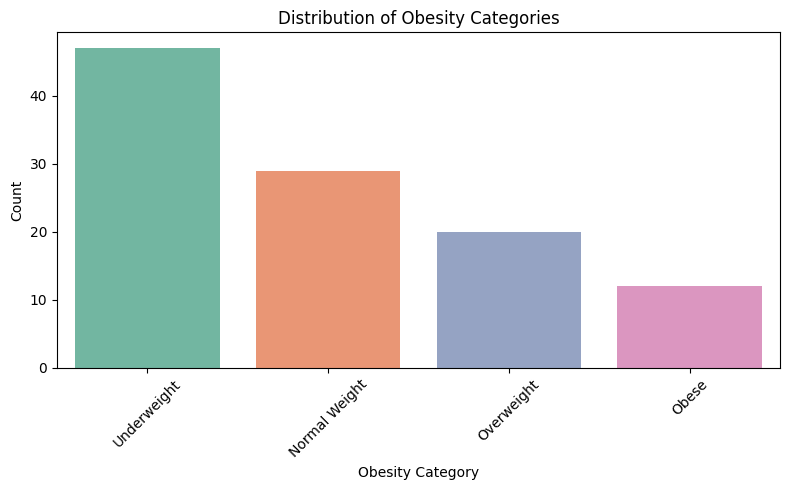

In [27]:
# Box plot - Distribution of Obesity
plt.figure(figsize=(8,5))
sns.countplot(data=df_cleaned, x='Label', order=df_cleaned['Label'].value_counts().index, palette='Set2')
plt.title("Distribution of Obesity Categories")
plt.xlabel("Obesity Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/nw/c745mgyj79lf4r0gkq4qslmr0000gn/T/ipykernel_12274/3497806352.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='Label', y='BMI', palette='Set3')


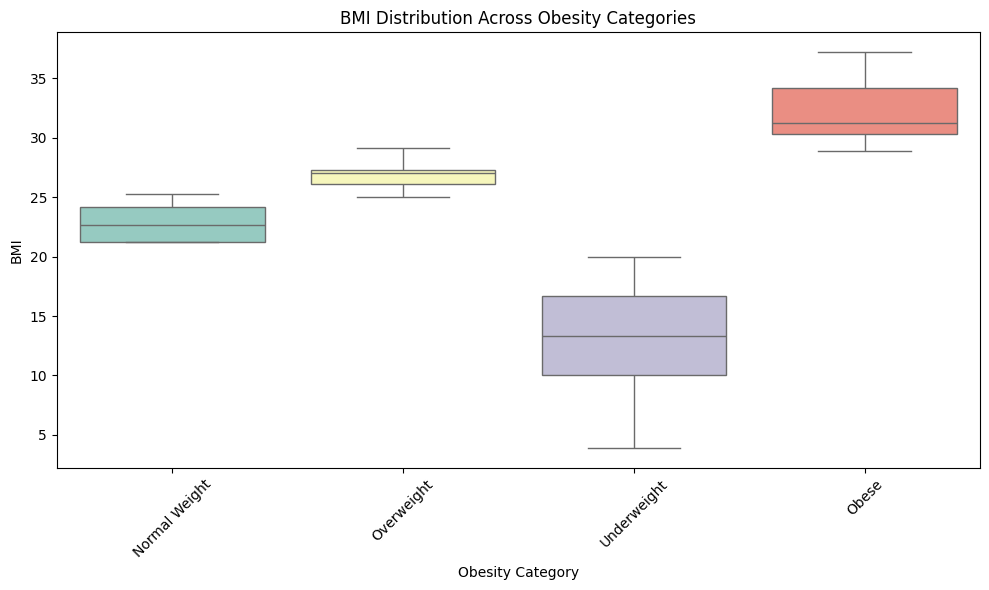

In [28]:
# BMI Distribution to Obesity 
plt.figure(figsize=(10,6))
sns.boxplot(data=df_cleaned, x='Label', y='BMI', palette='Set3')
plt.title("BMI Distribution Across Obesity Categories")
plt.xlabel("Obesity Category")
plt.ylabel("BMI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

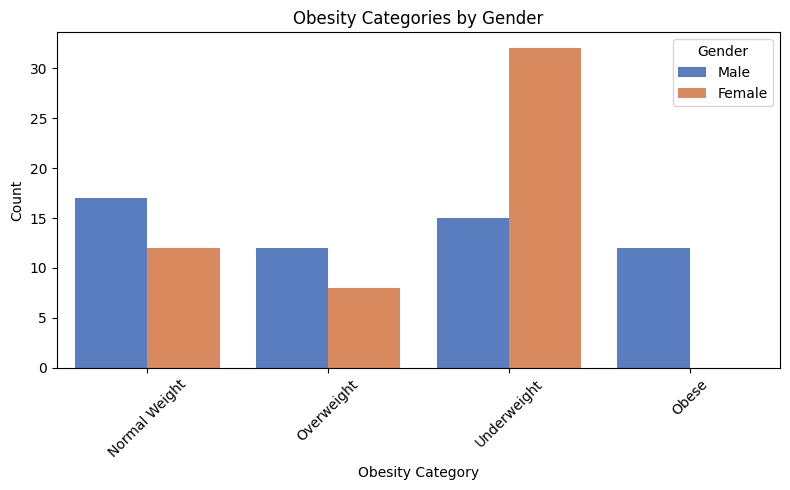

In [29]:
# Box plot - Obesity Categories by Gender
plt.figure(figsize=(8,5))
sns.countplot(data=df_cleaned, x='Label', hue='Gender', palette='muted')
plt.title("Obesity Categories by Gender")
plt.xlabel("Obesity Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

StandardScaler standardizes the features by removing the mean and scaling to unit variance. This means the transformed data will have a mean of 0 and a standard deviation of 1.

Random Forest Accuracy: 0.9545
Support Vector Machine Accuracy: 1.0000

--- Random Forest Detailed Report ---
               precision    recall  f1-score   support

Normal Weight       1.00      0.83      0.91         6
        Obese       1.00      1.00      1.00         4
   Overweight       0.80      1.00      0.89         4
  Underweight       1.00      1.00      1.00         8

     accuracy                           0.95        22
    macro avg       0.95      0.96      0.95        22
 weighted avg       0.96      0.95      0.96        22


--- Support Vector Machine Detailed Report ---
               precision    recall  f1-score   support

Normal Weight       1.00      1.00      1.00         6
        Obese       1.00      1.00      1.00         4
   Overweight       1.00      1.00      1.00         4
  Underweight       1.00      1.00      1.00         8

     accuracy                           1.00        22
    macro avg       1.00      1.00      1.00        22
 weighted av

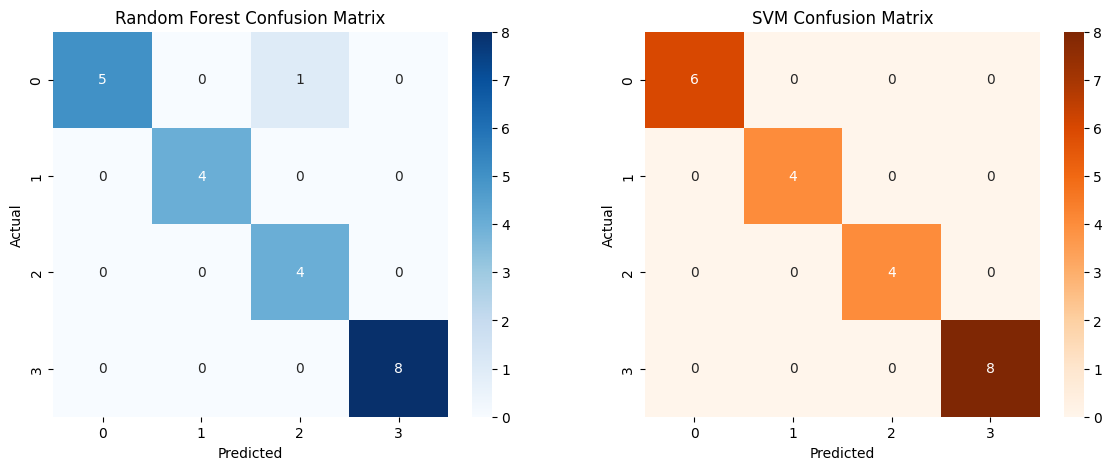


Sample Predictions Comparison:
    Actual Label  RF Prediction SVM Prediction
0  Normal Weight  Normal Weight  Normal Weight
1  Normal Weight  Normal Weight  Normal Weight
2          Obese          Obese          Obese
3    Underweight    Underweight    Underweight
4  Normal Weight  Normal Weight  Normal Weight
5     Overweight     Overweight     Overweight
6  Normal Weight  Normal Weight  Normal Weight
7     Overweight     Overweight     Overweight
8    Underweight    Underweight    Underweight
9    Underweight    Underweight    Underweight


In [ ]:
# Feature-target separation
# We exclude 'ID' as it is just an index and 'Label' as it is the target
X = df_cleaned[['Age', 'Gender', 'Height', 'Weight', 'BMI']]
y = df_cleaned['Label']

# One-hot encode 'Gender'
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Model 2: Support Vector Machine (Classification) (SVC)
svc_model = SVC(kernel='linear', random_state=42)
svc_model.fit(X_train_scaled, y_train)

# 5. Make Predictions
rf_pred = rf_model.predict(X_test_scaled)
svc_pred = svc_model.predict(X_test_scaled)

# 6. Evaluate and Compare Results
rf_acc = accuracy_score(y_test, rf_pred)
svc_acc = accuracy_score(y_test, svc_pred)

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Support Vector Machine Accuracy: {svc_acc:.4f}")

print("\n--- Random Forest Detailed Report ---")
print(classification_report(y_test, rf_pred))

print("\n--- Support Vector Machine Detailed Report ---")
print(classification_report(y_test, svc_pred))

# 7. Visualize Evaluation (Confusion Matrices)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap="Blues", ax=ax[0])
ax[0].set_title("Random Forest Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, svc_pred), annot=True, fmt='d', cmap="Oranges", ax=ax[1])
ax[1].set_title("SVM Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.show()

# 8. Comparison Table (Sample Predictions)
results_df = pd.DataFrame({
    "Actual Label": y_test.values,
    "RF Prediction": rf_pred,
    "SVM Prediction": svc_pred
})
print("\nSample Predictions Comparison:")
print(results_df.head(10))